# Decomposition Results: TFIM vs Naive vs Trotter

## Load data

In [69]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find Results/ whether this notebook runs from Results/ or the repo root
results_dir = os.getcwd()
if os.path.basename(results_dir) != "Results" and os.path.isdir("Results"):
    results_dir = os.path.abspath("Results")

def load(name):
    path = os.path.join(results_dir, name)
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        print(f"(missing) {name}")
        return None
    df = pd.read_csv(path, skipinitialspace=True, na_values=["N/A"])
    df.columns = df.columns.str.strip()
    # append-mode files can accumulate duplicates across re-runs; keep the latest
    keys = [k for k in ("n_qubits", "trotter_steps") if k in df.columns]
    if keys:
        df = df.drop_duplicates(keys, keep="last").sort_values(keys).reset_index(drop=True)
    return df

# All three pipelines now write a single results file with a common schema:
#   n_qubits, total_time, decomposition_time, error, total_gates, cnot, single_qubit, elementary_total
# (Trotter additionally carries trotter_steps and verification_time.)
tfim  = load("TFIM_decomposition_results.txt")
trot  = load("TFIM_trotter_results.txt")
naive = load("Naive_decomposition_results.txt")

# Representative Trotter slice for the vs-n comparisons: r = n
trot_rep = None
if trot is not None:
    trot_rep = (trot[trot["trotter_steps"] == trot["n_qubits"]]
                .drop_duplicates("n_qubits", keep="last").sort_values("n_qubits"))

for label, df in [("TFIM", tfim), ("Trotter", trot), ("Naive", naive)]:
    print(f"{label:8s}: {0 if df is None else len(df)} rows")

# --- plotting hygiene for log-scale error plots ---
# n=1 is degenerate: the TFIM Hamiltonian has no coupling term (single-site field
# only), so first-order Trotter is exact and the error is ~0, which collapses or
# gaps on a log axis. Likewise, reconstruction errors below ERR_FLOOR are
# floating-point noise (the exact methods sit at machine precision). We drop both.
N_MIN = 2
ERR_FLOOR = 1e-14

def clean_err(df):
    """Drop NaN errors, n < N_MIN, and sub-ERR_FLOOR noise for log-scale plots."""
    if df is None or "error" not in df:
        return None
    d = df.dropna(subset=["error"])
    return d[(d["n_qubits"] >= N_MIN) & (d["error"] > ERR_FLOOR)]

def pos(df, col):
    """Rows with n >= N_MIN and a strictly positive `col` value (log-axis safe).
    At n=1 there is no coupling term, so cnot = 0 -> undefined on a log scale."""
    if df is None or col not in df:
        return None
    return df[(df["n_qubits"] >= N_MIN) & (df[col] > 0)]


TFIM    : 15 rows
Trotter : 99 rows
Naive   : 12 rows


## Elementary gate count vs n
TFIM (BDI) vs Naive (AIII+Type-A), with Trotter at the representative depth r = n.

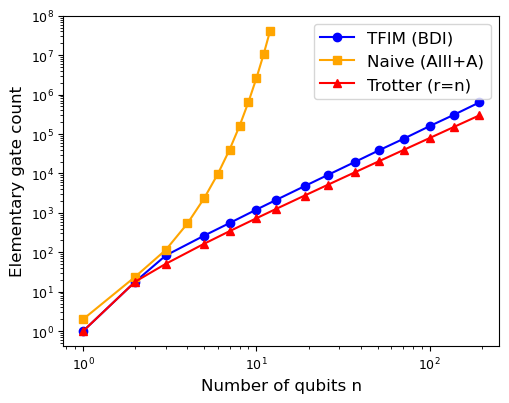

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
})

scaling_factor = 1.5
fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))

ax.plot(tfim["n_qubits"], tfim["elementary_total"], "o-", color="blue", label="TFIM (BDI)")
ax.plot(naive["n_qubits"], naive["elementary_total"], "s-", color="orange", label="Naive (AIII+A)")
ax.plot(trot_rep["n_qubits"], trot_rep["elementary_total"], "^-", color="red", label="Trotter (r=n)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Elementary gate count")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "gate_count_comparison.png"), dpi=150)
plt.show()


## CNOT count vs n
The hardware-relevant two-qubit gate count.

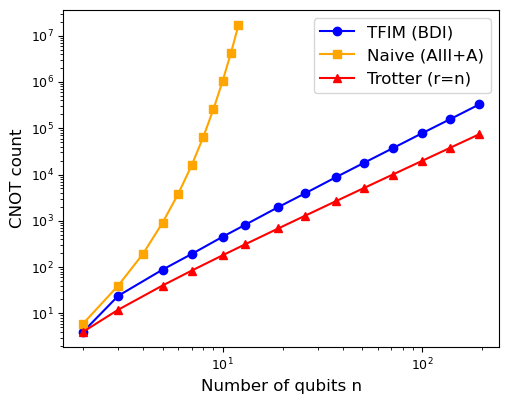

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
})

scaling_factor = 1.5
fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))

thry = np.linspace(2, 200, 100)

# n=1 has no coupling term -> cnot = 0 (undefined on a log axis); drop it.
_t, _n, _r = pos(tfim, "cnot"), pos(naive, "cnot"), pos(trot_rep, "cnot")
ax.plot(_t["n_qubits"], _t["cnot"], "o-", color="blue", label="TFIM (BDI)")
ax.plot(_n["n_qubits"], _n["cnot"], "s-", color="orange", label="Naive (AIII+A)")
ax.plot(_r["n_qubits"], _r["cnot"], "^-", color="red", label="Trotter (r=n)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("CNOT count")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "CNOT_count.png"), dpi=150)
plt.show()


## Pauli Gate Count vs n
Also plot the total gate counts before turning it into elementary gates for comparison.

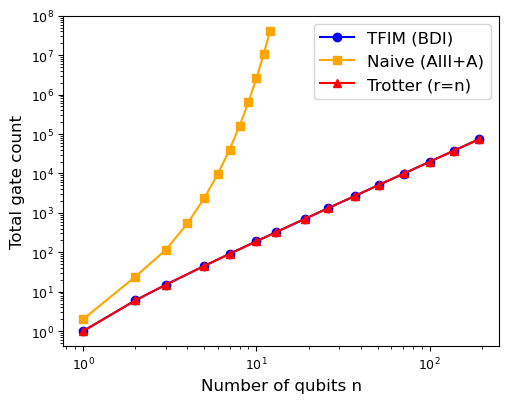

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
})

scaling_factor = 1.5
fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))

thry = np.linspace(2, 200, 100)

ax.plot(tfim["n_qubits"], tfim["total_gates"], "o-", color="blue", label="TFIM (BDI)")
ax.plot(naive["n_qubits"], naive["total_gates"], "s-", color="orange", label="Naive (AIII+A)")
ax.plot(trot_rep["n_qubits"], trot_rep["total_gates"], "^-", color="red", label="Trotter (r=n)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Total gate count")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "total_gate_count.png"), dpi=150)
plt.show()


## Decomposition time vs n
TFIM vs Naive. (Trotter's decomposition is analytic — microseconds — so it is omitted here
and characterised separately below.) Only `decomposition_time` is comparable across methods;
`total_time` includes each method's very different setup cost.

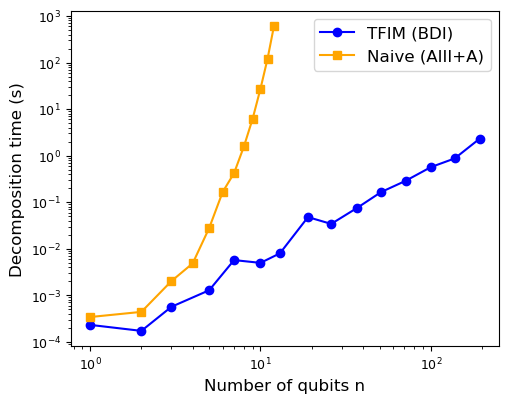

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
})

scaling_factor = 1.5
fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))

ax.plot(tfim["n_qubits"], tfim["decomposition_time"], "o-", color="blue", label="TFIM (BDI)")
ax.plot(naive["n_qubits"], naive["decomposition_time"], "s-", color="orange", label="Naive (AIII+A)")
#ax.plot(trot_rep["n_qubits"], trot_rep["decomposition_time"], "^-", color="red", label="Trotter (r=n)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Decomposition time (s)")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "decomposition_time_comparison.png"), dpi=150)
plt.show()


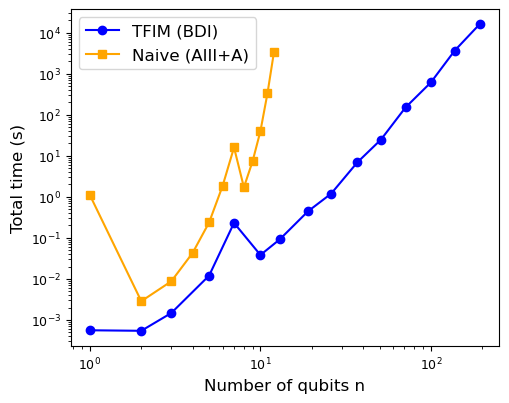

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
})

scaling_factor = 1.5
fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))

ax.plot(tfim["n_qubits"], tfim["total_time"], "o-", color="blue", label="TFIM (BDI)")
ax.plot(naive["n_qubits"], naive["total_time"], "s-", color="orange", label="Naive (AIII+A)")
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Total time (s)")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "total_time_comparison.png"), dpi=150)
plt.show()

## Reconstruction error vs n
Available only for small n. **Note:** TFIM and Naive errors are *numerical* (both are exact
decompositions, so ~1e-14), whereas Trotter error is *algorithmic* (first-order Trotter is an
approximation) — they are qualitatively different and shown together only for context.

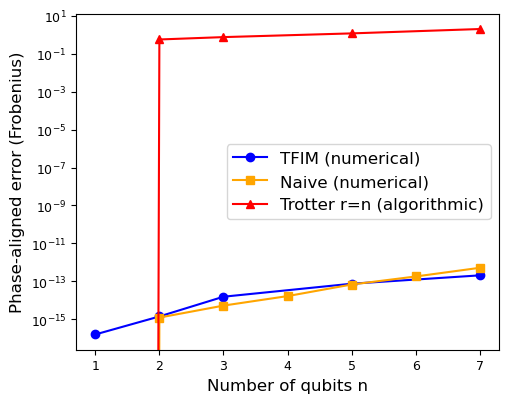

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 12,
})

scaling_factor = 1.5
fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))

for df, lab, c, m in [(tfim, "TFIM (numerical)", "blue", "o"),
                      (naive, "Naive (numerical)", "orange", "s"),
                      (trot_rep, "Trotter r=n (algorithmic)", "red", "^")]:
    if df is not None and len(df):
        ax.plot(df["n_qubits"], df["error"], m + "-", color=c, label=lab)
ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Phase-aligned error (Frobenius)")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "reconstruction_error.png"), dpi=150)
plt.show()


## Trotter characterisation: error and gate count vs Trotter steps r

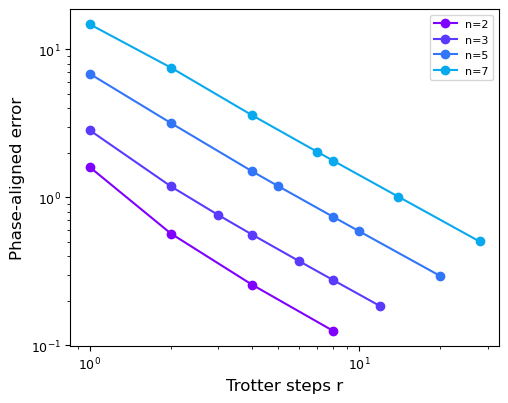

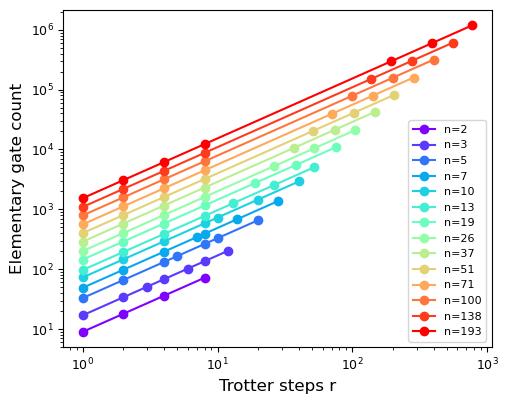

In [85]:
ns = sorted(n for n in trot["n_qubits"].unique() if n >= N_MIN)
cmap = plt.cm.rainbow
colors = {n: cmap(i / (len(ns) - 1)) for i, n in enumerate(ns)}

for (col, ylabel, save_file) in ([
        ("error", "Phase-aligned error", "trotter_error.png"),
        ("elementary_total", "Elementary gate count", "trotter_gate_count.png"),
    ]):
        plt.rcParams.update({
            "font.size": 12,
            "axes.labelsize": 12,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 12,
        })

        # Plot only the risk-return tradeoff
        scaling_factor = 1.5
        fig, ax = plt.subplots(figsize=(3.5*scaling_factor, 2.8*scaling_factor))
        for n, g in trot.groupby("n_qubits"):
            if n < N_MIN:
                continue
            g = g.sort_values("trotter_steps")
            if col == "error":
                g = g.dropna(subset=["error"])
                g = g[g["error"] > ERR_FLOOR]
            if len(g):
                ax.plot(g["trotter_steps"], g[col], "o-", label=f"n={n}", color=colors[n])

        ax.set_xlabel("Trotter steps r")
        ax.set_ylabel(ylabel)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(results_dir, save_file), dpi=150)
        plt.show()


## Scaling fits

**TFIM** and **Trotter** are polynomial in n, so a power law `y ~ n^b` is the right model.
**Naive** is general unitary synthesis: its cost is `O(4^n)` — *exponential* in n — so a power-law
slope is only a local descriptor (it grows with the fit range). The exponential fit `log(y) = a + c·n`
is the meaningful one for Naive.

In [76]:
def fit_power(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return None
    b, _ = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
    return b

def fit_exp(x, y):
    # log(y) = a + c*n  ->  y ~ exp(c)^n; report the base exp(c)
    x = np.asarray(x, float); y = np.asarray(y, float)
    mask = (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return None
    c, _ = np.polyfit(x[mask], np.log(y[mask]), 1)
    return np.exp(c)

def pw(label, b):
    print(f"{label:26s} ~ n^{b:.2f}" if b is not None else f"{label:26s}: insufficient data")

print("Polynomial (power-law) fits  y ~ n^b:")
if tfim is not None:
    pw("  TFIM  elementary gates", fit_power(tfim['n_qubits'], tfim['elementary_total']))
    pw("  TFIM  CNOT count",       fit_power(tfim['n_qubits'], tfim['cnot']))
    pw("  TFIM  decomp time",      fit_power(tfim['n_qubits'], tfim['decomposition_time']))

print()
print("Naive is O(4^n) - exponential fit  y ~ base^n:")
if naive is not None:
    be = fit_exp(naive['n_qubits'], naive['elementary_total'])
    bc = fit_exp(naive['n_qubits'], naive['cnot'])
    print(f"  Naive elementary gates ~ {be:.2f}^n   (ideal general-unitary cost ~ 4^n)" if be else "  insufficient data")
    print(f"  Naive CNOT count       ~ {bc:.2f}^n" if bc else "")
    if 'decomposition_time' in naive:
        bt = fit_exp(naive['n_qubits'], naive['decomposition_time'])
        print(f"  Naive decomp time      ~ {bt:.2f}^n" if bt else "")


Polynomial (power-law) fits  y ~ n^b:
  TFIM  elementary gates   ~ n^2.35
  TFIM  CNOT count         ~ n^2.36
  TFIM  decomp time        ~ n^1.88

Naive is O(4^n) - exponential fit  y ~ base^n:
  Naive elementary gates ~ 4.38^n   (ideal general-unitary cost ~ 4^n)
  Naive CNOT count       ~ 4.30^n
  Naive decomp time      ~ 3.86^n


## Full pipeline time